# 🐼 Jour 1 — Découverte de pandas avec le dataset California Housing

**Objectif :** apprendre les opérations de base de pandas : charger un CSV, inspecter les données, supprimer des colonnes, tracer des graphiques.

- `pd.read_csv("housing.csv")` : lit le fichier CSV → **DataFrame** (tableau lignes × colonnes)
- `.columns` : affiche la liste des colonnes du dataset

In [2]:
import pandas as pd
df = pd.read_csv("housing.csv")
df.columns



Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

`os.getcwd()` (*get current working directory*) : affiche le **dossier de travail courant**. Utile pour comprendre où Python cherche le fichier CSV quand on donne un chemin relatif comme `"housing.csv"`.

In [12]:
import os
os.getcwd()

'c:\\Users\\kirit\\Documents\\Projets\\Cours_Python\\Cours_IA'

`.head(10)` : affiche les **10 premières lignes** — premier réflexe pour vérifier que les données sont bien chargées.

In [13]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Affichage du DataFrame entier (Jupyter tronque automatiquement l'affichage au milieu s'il y a trop de lignes).

In [11]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### 🧠 Théorie : l'histogramme

Un histogramme montre la **distribution** d'une variable : on découpe la plage des valeurs en intervalles (*bins*) et on compte combien de valeurs tombent dans chaque intervalle. La hauteur de chaque barre = ce compte.

👉 Il permet de voir en un coup d'œil : où se concentrent les valeurs, si la distribution est symétrique, et s'il y a des pics anormaux (ici, le pic à droite sur l'âge médian vient d'un plafonnement des données à ~52 ans).

array([[<Axes: title={'center': 'housing_median_age'}>]], dtype=object)

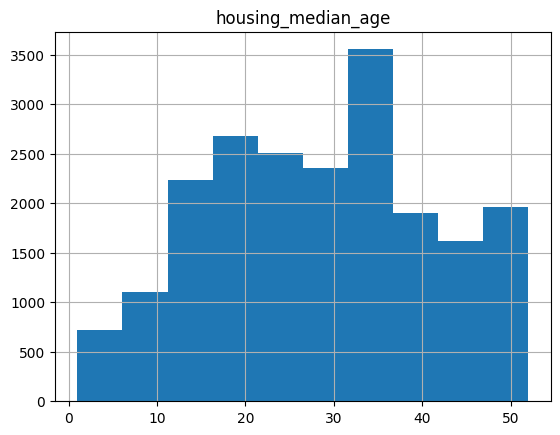

In [3]:
df.hist("housing_median_age")

`.drop(["longitude","latitude"], axis=1)` : supprime **deux colonnes** d'un coup (les coordonnées GPS, pas utiles pour cette analyse). `axis=1` = colonnes ; sans réaffectation `df = ...`, le DataFrame ne serait pas modifié.

In [4]:
df = df.drop(["longitude","latitude"], axis = 1)



`.head()` sans argument = les **5 premières** lignes par défaut. On vérifie que les colonnes ont bien disparu.

In [18]:
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


`.tail(10)` : les **10 dernières** lignes (l'inverse de `head`).

In [19]:
df.tail(10)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20630,11.0,2640.0,505.0,1257.0,445.0,3.5673,112000.0,INLAND
20631,15.0,2655.0,493.0,1200.0,432.0,3.5179,107200.0,INLAND
20632,15.0,2319.0,416.0,1047.0,385.0,3.1250,115600.0,INLAND
20633,27.0,2080.0,412.0,1082.0,382.0,2.5495,98300.0,INLAND
20634,28.0,2332.0,395.0,1041.0,344.0,3.7125,116800.0,INLAND
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


`.head(100).plot(y="population")` : trace la colonne `population` des **100 premières lignes** sous forme de **courbe** (l'axe x = le numéro de ligne / l'index). Attention : l'ordre des lignes n'a pas de sens particulier ici, c'est surtout un exercice de tracé.

<Axes: >

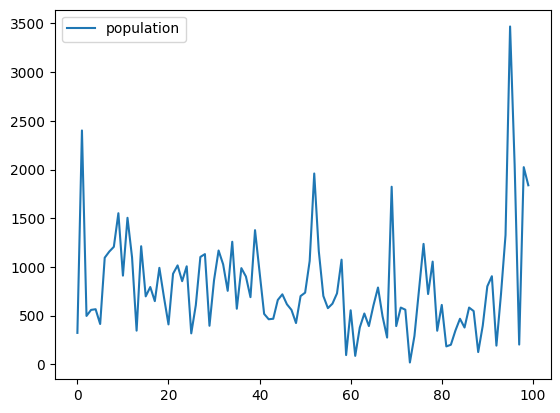

In [22]:
df.head(100).plot(y = "population")

`df.hist()` sans argument : trace **un histogramme pour chaque colonne numérique** du DataFrame — un moyen ultra-rapide d'avoir une vue d'ensemble de toutes les distributions.

**🔍 Comment scanner rapidement toute une grille d'histogrammes :**
- **Forme symétrique (en cloche)** : variable proche d'une distribution normale — plutôt rassurant pour beaucoup de méthodes statistiques.
- **Asymétrie (skew) à droite** : une longue traîne de valeurs élevées peu fréquentes (typique de `median_income` ou `total_rooms` — quelques quartiers très riches ou très denses tirent la moyenne vers le haut).
- **Pic isolé tout à droite (ou tout à gauche)** : souvent un signe de **plafonnement des données** (comme `housing_median_age` vu plus haut, plafonné à 52 ans) — les valeurs au-delà de la limite sont toutes regroupées dans la dernière barre.
- **Distribution bimodale (deux bosses)** : peut indiquer que la colonne mélange en réalité deux populations différentes (ex : deux types de quartiers).

array([[<Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>, <Axes: >,
        <Axes: >]], dtype=object)

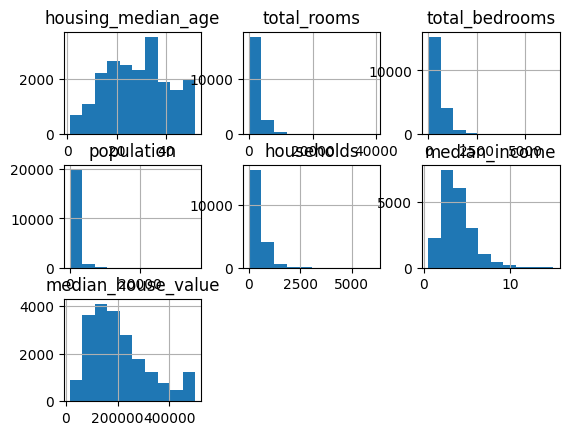

In [23]:
df.hist()

Nuage de points `total_rooms` vs `total_bedrooms` : on s'attend à une **forte corrélation linéaire** (plus un quartier a de pièces au total, plus il a de chambres) — et c'est bien ce qu'on observe : les points forment presque une droite.

<Axes: xlabel='total_rooms', ylabel='total_bedrooms'>

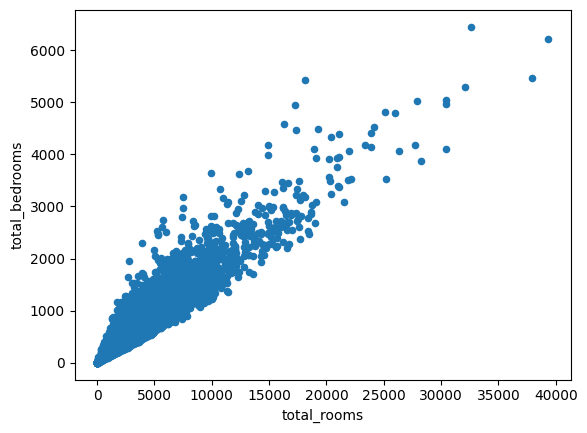

In [25]:
df.plot.scatter(x="total_rooms",y="total_bedrooms")

`.describe()` : les statistiques descriptives de chaque colonne numérique — `count` (nombre), `mean` (moyenne $\bar{x} = \frac{1}{n}\sum x_i$), `std` (écart-type, la dispersion), `min`/`max`, et les **quartiles** 25 % / 50 % (médiane) / 75 %.

In [26]:
df.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Les types Python et pandas
`type(...)` révèle le type d'un objet. Les trois cellules suivantes montrent la hiérarchie :
- `9` → **`int`** (entier Python de base)
- `df` → **`DataFrame`** (tableau 2D pandas : plusieurs colonnes)
- `df["total_rooms"]` → **`Series`** (1 colonne = tableau 1D avec un index)

👉 À retenir : **une colonne extraite d'un DataFrame est une Series.**

In [27]:
type(9)

int

In [28]:
type(df)

pandas.DataFrame

In [30]:
type(df["total_rooms"])

pandas.Series